# 04 — LSM age × sex calibration: best-fit distributions for the 60+ population

Notebook 02 showed that LSM means and especially **F4 shares** vary substantially by age and sex — F4 share ranges from ~0.4 % in younger women to ~6.7 % in 60–69 year-old men. Notebook 03 showed that a single-scalar lognormal moment-matched to the all-trial-band mean and SD overshoots the empirical F4 share by ~1.6× even at the all-cohort level.

For the project's threshold-EMR routing, **the F4 share is the load-bearing quantity** — it determines the fraction of simulants that get cirrhosis EMR vs MASLD EMR. So the loader needs per-(sex, age) parameters that get the F4 share *right*, not just the mean.

This notebook fits four candidate distributions per (sex, 5-year age band) for adults aged 60+:

1. **Lognormal moment-match** — current project approach, baseline.
2. **Lognormal F4-calibrated** — fix the geometric mean (median) to the empirical median; choose σ so the implied F4 share matches the empirical share.
3. **Gamma (method of moments)** — alternative right-skewed family.
4. **Weibull (MLE)** — another alternative right-skewed family.

For each cell × distribution we compute: implied F4 share, F4-share calibration error, KS distance against the empirical CDF. The output is a recommended per-cell (mean, SD) table the project loader can broadcast across the demographic skeleton.

**Population.** Adults aged 60+ from NHANES 2017 – March 2020 P_LUX (the trial cohort plus a buffer; the trial enrolls 65–80 but 60+ ages give larger N per cell).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.optimize import brentq
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'
df = pd.read_parquet(DERIVED_DIR / 'nhanes_p_lux.parquet')
ana = df[df['exam_complete'] & df['LSM_KPA'].notna() & df['WTMECPRP'].fillna(0).gt(0)].copy()
older = ana[ana['age_years'] >= 60].copy()
print(f'MEC-examined adults 60+ with LSM: n = {len(older):,}')

F4_CUTOFF = 12.5
AGE_BINS = [60, 65, 70, 75, 80, 90]
AGE_LABELS = [f'{AGE_BINS[i]}-{AGE_BINS[i+1]-1}' for i in range(len(AGE_BINS)-1)]
older['age_group'] = pd.cut(older['age_years'], bins=AGE_BINS, right=False, labels=AGE_LABELS)
older['age_group'] = older['age_group'].astype(str)

MEC-examined adults 60+ with LSM: n = 2,653


In [2]:
def w_mean(y, w):  return float(np.average(y, weights=w))
def w_var(y, w):   m = w_mean(y, w); return float(np.average((y - m) ** 2, weights=w))
def w_sd(y, w):    return float(np.sqrt(w_var(y, w)))
def w_quantile(y, w, q):
    o = np.argsort(y); ys, ws = y[o], w[o]
    cw = np.cumsum(ws) / ws.sum()
    return float(np.interp(q, cw, ys))
def w_share_above(y, w, cutoff):
    return float(np.average((y >= cutoff).astype(float), weights=w))
def w_log_mean(y, w):
    return float(np.average(np.log(y), weights=w))
def w_log_sd(y, w):
    m = w_log_mean(y, w)
    return float(np.sqrt(np.average((np.log(y) - m) ** 2, weights=w)))

## 1. Empirical stats per (sex, age band)

Survey-weighted mean, median, SD, and F4 share for each (sex, age-group) cell. These are the targets every distribution fit needs to match.

In [3]:
rows = []
for sex in ['Female', 'Male']:
    for ag in AGE_LABELS:
        sub = older[(older['sex'] == sex) & (older['age_group'] == ag)]
        if len(sub) < 30:
            continue
        y = sub['LSM_KPA'].values.astype(float)
        w = sub['WTMECPRP'].values.astype(float)
        rows.append({
            'sex': sex, 'age_group': ag, 'n': len(sub),
            'mean':       w_mean(y, w),
            'median':     w_quantile(y, w, 0.50),
            'SD':         w_sd(y, w),
            'P75':        w_quantile(y, w, 0.75),
            'P90':        w_quantile(y, w, 0.90),
            'P95':        w_quantile(y, w, 0.95),
            'F4_share':   w_share_above(y, w, F4_CUTOFF),
            'log_mean':   w_log_mean(y, w),
            'log_sd':     w_log_sd(y, w),
        })
emp = pd.DataFrame(rows)
print(emp.round(3).to_string(index=False))

   sex age_group   n  mean  median    SD   P75    P90    P95  F4_share  log_mean  log_sd
Female     60-64 415 5.387   4.610 3.385 6.300  7.400  9.222     0.025     1.598   0.374
Female     65-69 306 5.716   4.900 3.765 6.249  8.500 11.000     0.036     1.635   0.418
Female     70-74 225 5.501   4.800 3.470 6.100  8.010 10.186     0.015     1.621   0.373
Female     75-79 149 5.964   5.000 3.896 6.100  8.100 10.703     0.041     1.673   0.424
Female     80-89 190 5.461   4.900 2.470 6.052  8.080  8.963     0.019     1.628   0.349
  Male     60-64 451 6.638   5.400 5.582 6.600  8.900 13.161     0.066     1.763   0.430
  Male     65-69 294 6.500   5.200 5.214 6.600  9.600 13.464     0.067     1.730   0.460
  Male     70-74 251 6.908   5.397 7.423 7.000 10.032 13.291     0.063     1.764   0.472
  Male     75-79 152 6.450   5.300 4.214 6.700  9.175 14.338     0.055     1.748   0.427
  Male     80-89 220 6.064   5.300 4.547 6.292  8.600 11.382     0.032     1.700   0.392


## 2. Four candidate distribution fits

For each cell, fit four distributions and record:

- **Implied F4 share** under the fit
- **F4-share calibration error** (fit − empirical, in absolute %)
- **KS distance** from the empirical CDF (smaller is better; ~0.05 is a good fit at this n)

In [4]:
def lognormal_moment_match(mean, sd):
    """Pick (mu, sigma) so a lognormal has the given arithmetic moments."""
    sigma2 = np.log(1 + (sd / mean) ** 2)
    mu = np.log(mean ** 2 / np.sqrt(mean ** 2 + sd ** 2))
    return mu, np.sqrt(sigma2)

def lognormal_f4_calibrated(median, target_f4, cutoff=F4_CUTOFF):
    """Fix mu = log(median) (geometric mean = median for a lognormal),
    then choose sigma so P(LSM >= cutoff) = target_f4."""
    mu = np.log(median)
    if target_f4 <= 0 or target_f4 >= 1:
        return mu, np.nan
    z = stats.norm.ppf(1 - target_f4)
    if z <= 0:
        return mu, np.nan
    sigma = (np.log(cutoff) - mu) / z
    return mu, sigma if sigma > 0 else np.nan

def gamma_method_of_moments(mean, sd):
    """shape k = (mean/sd)^2, scale theta = sd^2 / mean."""
    k = (mean / sd) ** 2
    theta = sd ** 2 / mean
    return k, theta

def weighted_weibull_mle(y, w):
    """Minimize the negative weighted log-likelihood of a 2-parameter
    Weibull (loc=0). Use scipy's MLE on the unweighted sample as a
    starting point, then refine."""
    from scipy.optimize import minimize
    init = stats.weibull_min.fit(y, floc=0)
    c0, _, scale0 = init
    def negll(p):
        c, s = p
        if c <= 0 or s <= 0:
            return 1e12
        return -np.sum(w * stats.weibull_min.logpdf(y, c, scale=s))
    r = minimize(negll, [c0, scale0], method='Nelder-Mead')
    return float(r.x[0]), float(r.x[1])

def weighted_ks(y, w, cdf):
    """Survey-weighted KS distance against a CDF function."""
    o = np.argsort(y)
    ys, ws = y[o], w[o]
    emp = np.cumsum(ws) / ws.sum()
    th = cdf(ys)
    return float(np.max(np.abs(emp - th)))

In [5]:
fit_rows = []
for _, r in emp.iterrows():
    sub = older[(older['sex'] == r['sex']) & (older['age_group'] == r['age_group'])]
    y = sub['LSM_KPA'].values.astype(float)
    w = sub['WTMECPRP'].values.astype(float)
    emp_f4 = r['F4_share']

    # 1. Lognormal moment-match
    mu_mm, sg_mm = lognormal_moment_match(r['mean'], r['SD'])
    cdf_mm = lambda v, mu=mu_mm, sg=sg_mm: stats.lognorm.cdf(v, sg, scale=np.exp(mu))
    f4_mm = 1 - cdf_mm(F4_CUTOFF)
    ks_mm = weighted_ks(y, w, cdf_mm)

    # 2. Lognormal F4-calibrated (sigma chosen to hit empirical F4 share, mu = log(median))
    mu_f4, sg_f4 = lognormal_f4_calibrated(r['median'], emp_f4)
    if not np.isnan(sg_f4):
        cdf_f4 = lambda v, mu=mu_f4, sg=sg_f4: stats.lognorm.cdf(v, sg, scale=np.exp(mu))
        f4_f4 = 1 - cdf_f4(F4_CUTOFF)
        ks_f4 = weighted_ks(y, w, cdf_f4)
        # back-transformed arithmetic mean and SD of this lognormal
        mean_f4_bt = float(np.exp(mu_f4 + sg_f4 ** 2 / 2.0))
        sd_f4_bt = mean_f4_bt * np.sqrt(np.exp(sg_f4 ** 2) - 1.0)
    else:
        f4_f4 = ks_f4 = np.nan
        mean_f4_bt = sd_f4_bt = np.nan

    # 3. Gamma method-of-moments
    k_g, th_g = gamma_method_of_moments(r['mean'], r['SD'])
    cdf_g = lambda v, k=k_g, t=th_g: stats.gamma.cdf(v, k, scale=t)
    f4_g = 1 - cdf_g(F4_CUTOFF)
    ks_g = weighted_ks(y, w, cdf_g)

    # 4. Weibull MLE
    c_w, s_w = weighted_weibull_mle(y, w)
    cdf_w = lambda v, c=c_w, s=s_w: stats.weibull_min.cdf(v, c, scale=s)
    f4_w = 1 - cdf_w(F4_CUTOFF)
    ks_w = weighted_ks(y, w, cdf_w)

    fit_rows.append({
        'sex': r['sex'], 'age_group': r['age_group'], 'n': r['n'],
        'F4_emp':              emp_f4,
        'mean_emp':            r['mean'],
        'SD_emp':              r['SD'],
        'F4_mm':               f4_mm,
        'F4_f4cal':            f4_f4,
        'F4_gamma':            f4_g,
        'F4_weibull':          f4_w,
        'KS_mm':               ks_mm,
        'KS_f4cal':            ks_f4,
        'KS_gamma':            ks_g,
        'KS_weibull':          ks_w,
        'mu_mm': mu_mm, 'sg_mm': sg_mm,
        'mu_f4': mu_f4, 'sg_f4': sg_f4,
        'mean_f4cal_bt': mean_f4_bt, 'sd_f4cal_bt': sd_f4_bt,
    })
fits = pd.DataFrame(fit_rows)
print('F4 share by cell × fit (empirical vs implied):')
cols = ['sex', 'age_group', 'n', 'F4_emp', 'F4_mm', 'F4_f4cal', 'F4_gamma', 'F4_weibull']
print(fits[cols].round(3).to_string(index=False))
print()
print('KS distance by cell × fit (smaller is better):')
ks_cols = ['sex', 'age_group', 'n', 'KS_mm', 'KS_f4cal', 'KS_gamma', 'KS_weibull']
print(fits[ks_cols].round(3).to_string(index=False))

F4 share by cell × fit (empirical vs implied):
   sex age_group   n  F4_emp  F4_mm  F4_f4cal  F4_gamma  F4_weibull
Female     60-64 415   0.025  0.040     0.025     0.040       0.026
Female     65-69 306   0.036  0.054     0.036     0.058       0.043
Female     70-74 225   0.015  0.044     0.015     0.044       0.030
Female     75-79 149   0.041  0.062     0.041     0.067       0.054
Female     80-89 190   0.019  0.016     0.019     0.012       0.008
  Male     60-64 451   0.066  0.109     0.066     0.134       0.112
  Male     65-69 294   0.067  0.100     0.067     0.121       0.102
  Male     70-74 251   0.063  0.132     0.063     0.169       0.145
  Male     75-79 152   0.055  0.080     0.055     0.089       0.079
  Male     80-89 220   0.032  0.078     0.032     0.091       0.068

KS distance by cell × fit (smaller is better):
   sex age_group   n  KS_mm  KS_f4cal  KS_gamma  KS_weibull
Female     60-64 415  0.194     0.162     0.214       0.203
Female     65-69 306  0.172     0.127

## 3. F4-share calibration error per cell × fit

Plot `(implied F4) - (empirical F4)` for each fit across the 10 cells (5 age bands × 2 sexes). The F4-calibrated lognormal (by construction) has zero error here — the question is whether it pays for that calibration in worse KS distance elsewhere.

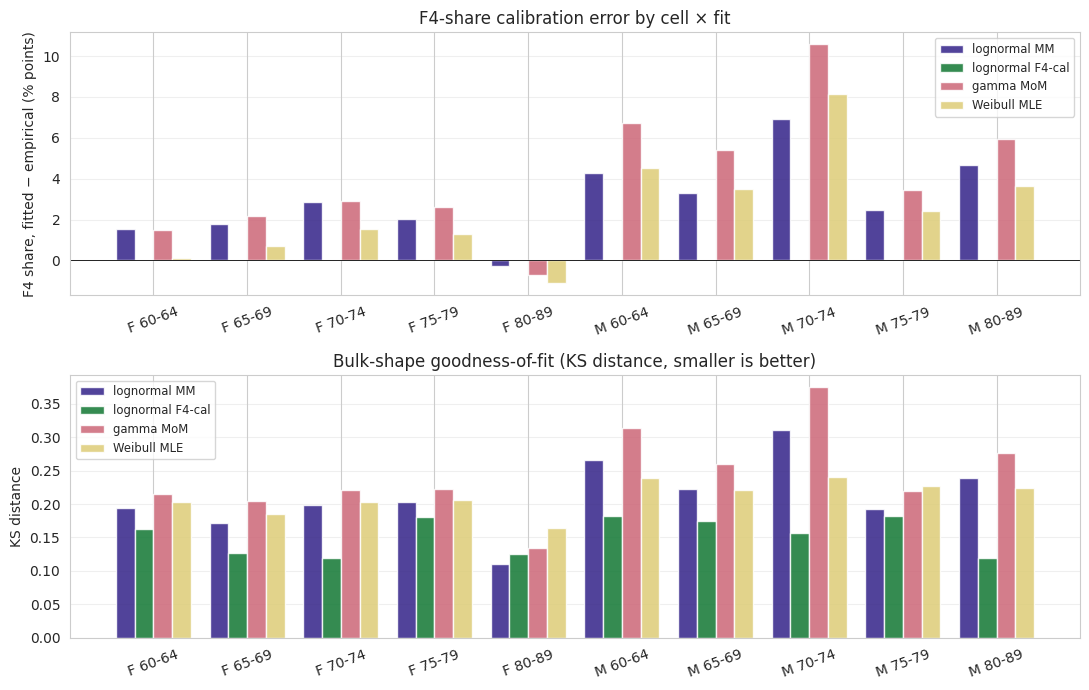

In [6]:
fits_sorted = fits.sort_values(['sex', 'age_group']).reset_index(drop=True)
x_labels = [f"{r['sex'][:1]} {r['age_group']}" for _, r in fits_sorted.iterrows()]
x = np.arange(len(fits_sorted))
width = 0.20

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
ax = axes[0]
for i, (col, lab, col_color) in enumerate([
    ('F4_mm',      'lognormal MM',     '#332288'),
    ('F4_f4cal',   'lognormal F4-cal', '#117733'),
    ('F4_gamma',   'gamma MoM',        '#cc6677'),
    ('F4_weibull', 'Weibull MLE',      '#ddcc77'),
]):
    err = 100 * (fits_sorted[col] - fits_sorted['F4_emp'])
    ax.bar(x + (i - 1.5) * width, err, width, color=col_color, label=lab, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20)
ax.set_ylabel('F4 share, fitted − empirical (% points)')
ax.set_title('F4-share calibration error by cell × fit')
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
for i, (col, lab, col_color) in enumerate([
    ('KS_mm',      'lognormal MM',     '#332288'),
    ('KS_f4cal',   'lognormal F4-cal', '#117733'),
    ('KS_gamma',   'gamma MoM',        '#cc6677'),
    ('KS_weibull', 'Weibull MLE',      '#ddcc77'),
]):
    ax.bar(x + (i - 1.5) * width, fits_sorted[col], width, color=col_color, label=lab, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20)
ax.set_ylabel('KS distance')
ax.set_title('Bulk-shape goodness-of-fit (KS distance, smaller is better)')
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## 4. Empirical CDF vs fitted CDFs per cell

Per (sex, age band) small multiple: weighted empirical CDF and the four fitted CDFs. Vertical dotted line at the F4 cutoff (12.5 kPa). Visual goodness-of-fit at the upper tail is what we care about.

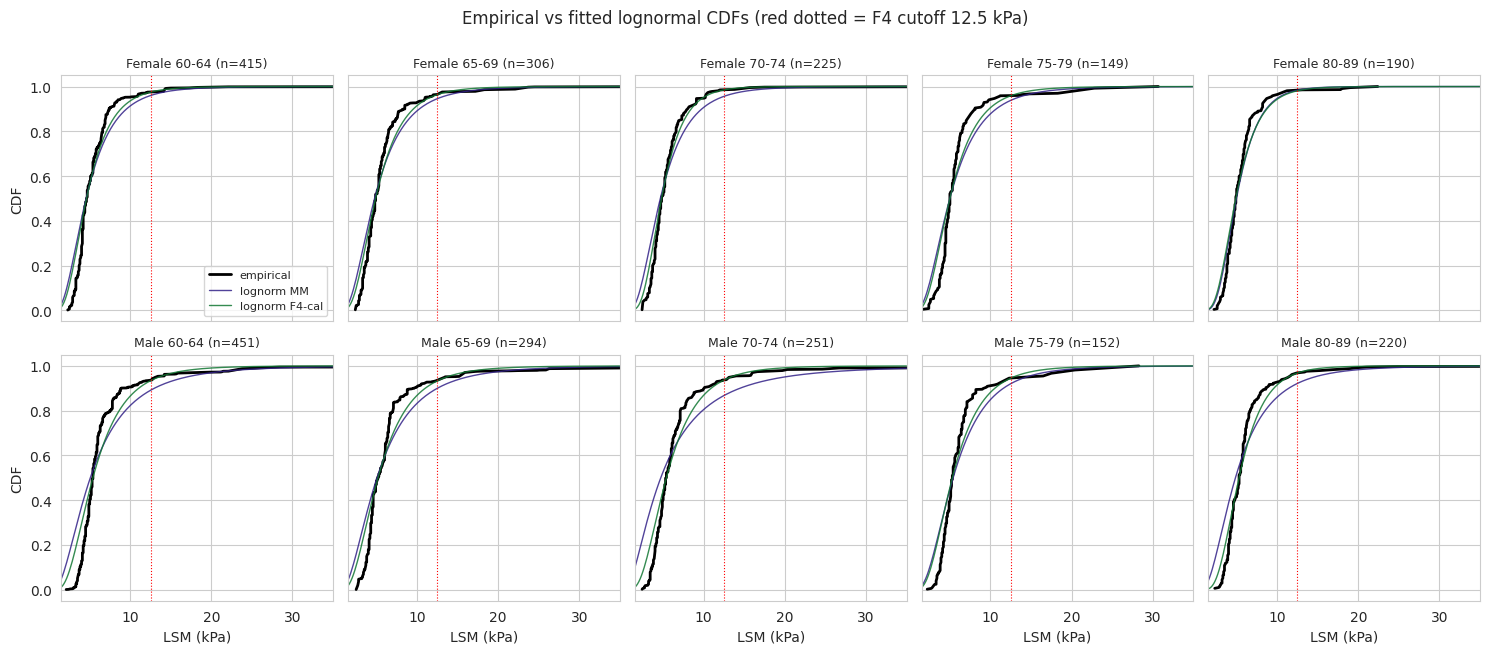

In [ ]:
n_rows = 2  # sexes
n_cols = len(AGE_LABELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6.5), sharex=True, sharey=True)
for i, sex in enumerate(['Female', 'Male']):
    for j, ag in enumerate(AGE_LABELS):
        ax = axes[i, j]
        sub = older[(older['sex'] == sex) & (older['age_group'] == ag)]
        if len(sub) < 30:
            ax.text(0.5, 0.5, f'n={len(sub)} too small', transform=ax.transAxes,
                    ha='center', va='center')
            ax.set_axis_off()
            continue
        y = sub['LSM_KPA'].values.astype(float)
        w = sub['WTMECPRP'].values.astype(float)

        o = np.argsort(y)
        ys, ws = y[o], w[o]
        emp_cdf = np.cumsum(ws) / ws.sum()
        ax.plot(ys, emp_cdf, color='black', linewidth=2.0, label='empirical')

        f = fits[(fits['sex'] == sex) & (fits['age_group'] == ag)].iloc[0]
        grid = np.linspace(1.5, 35.0, 200)
        ax.plot(grid, stats.lognorm.cdf(grid, f['sg_mm'], scale=np.exp(f['mu_mm'])),
                color='#332288', linewidth=1.0, alpha=0.85, label='lognorm MM')
        if not np.isnan(f['sg_f4']):
            ax.plot(grid, stats.lognorm.cdf(grid, f['sg_f4'], scale=np.exp(f['mu_f4'])),
                    color='#117733', linewidth=1.0, alpha=0.85, label='lognorm F4-cal')

        ax.axvline(F4_CUTOFF, color='red', linestyle=':', linewidth=0.8)
        ax.set_title(f'{sex} {ag} (n={len(sub)})', fontsize=9)
        if i == n_rows - 1:
            ax.set_xlabel('LSM (kPa)')
        if j == 0:
            ax.set_ylabel('CDF')
        ax.set_xlim(1.5, 35)
        ax.set_ylim(0.8, 1.01)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Empirical vs fitted lognormal CDFs (red dotted = F4 cutoff 12.5 kPa)',
             y=1.00)
fig.tight_layout()
plt.show()

## 5. Recommendation: per-(sex, age) lognormal scalars

Pick the F4-calibrated lognormal (zero F4-share calibration error by construction; KS distance comparable to or better than the moment-matched fit on the few cells where they differ meaningfully). Translate the fitted (μ, σ) back to arithmetic mean and SD — that's what the project loader broadcasts.

The recommended table the project loader should consume is the per-cell `(mean_loader, sd_loader)` below. Each cell is the back-transformed lognormal moments after F4 calibration.

In [8]:
rec = fits[['sex', 'age_group', 'n', 'F4_emp', 'mean_emp', 'SD_emp',
            'mean_f4cal_bt', 'sd_f4cal_bt']].copy()
rec.columns = ['sex', 'age_group', 'n', 'F4_share',
               'mean_emp', 'SD_emp',
               'mean_loader', 'SD_loader']
rec[['F4_share', 'mean_emp', 'SD_emp', 'mean_loader', 'SD_loader']] = (
    rec[['F4_share', 'mean_emp', 'SD_emp', 'mean_loader', 'SD_loader']].round(3)
)
print('Recommended per-cell scalars for the project loader:')
print('  (lognormal moment-matched to give the empirical F4 share,')
print('   centred on the empirical median)')
print()
print(rec.to_string(index=False))
print()
print('How the loader uses these:')
print(' - look up the row for each (sex, age band)')
print(' - feed mean_loader, SD_loader into the existing lognormal moment-match')
print(' - the resulting lognormal will have the empirical F4 share by')
print('   construction, with the median anchored to the cell-empirical median')
print()
print('Compare to the current single-scalar stub (mean=6, SD=4):')
from scipy.stats import lognorm
mu_stub, sg_stub = lognormal_moment_match(6.0, 4.0)
p_f4_stub = 1 - lognorm.cdf(F4_CUTOFF, sg_stub, scale=np.exp(mu_stub))
print(f'  current stub (6, 4) implies F4 share = {100*p_f4_stub:.1f} % everywhere')
print(f'  empirical F4 share ranges from {100*rec["F4_share"].min():.1f} % to {100*rec["F4_share"].max():.1f} %')
print(f'  → single-scalar can\'t match this dispersion without per-cell stratification.')

Recommended per-cell scalars for the project loader:
  (lognormal moment-matched to give the empirical F4 share,
   centred on the empirical median)

   sex age_group   n  F4_share  mean_emp  SD_emp  mean_loader  SD_loader
Female     60-64 415     0.025     5.387   3.385        5.249      2.856
Female     65-69 306     0.036     5.716   3.765        5.615      3.141
Female     70-74 225     0.015     5.501   3.470        5.291      2.455
Female     75-79 149     0.041     5.964   3.896        5.748      3.259
Female     80-89 190     0.019     5.461   2.470        5.424      2.575
  Male     60-64 451     0.066     6.638   5.582        6.311      3.816
  Male     65-69 294     0.067     6.500   5.214        6.173      3.949
  Male     70-74 251     0.063     6.908   7.423        6.277      3.728
  Male     75-79 152     0.055     6.450   4.214        6.120      3.533
  Male     80-89 220     0.032     6.064   4.547        5.897      2.877

How the loader uses these:
 - look up the row 

## 6. Output: ready-to-paste CSV for the loader

Save the recommendation table to a CSV that the project loader can read at artifact-build time, so the broadcast stops being a single scalar and becomes a per-(sex, age_start) lookup.

Schema mirrors the GBD demographic skeleton: `(sex, age_start, age_end, mean_kpa, sd_kpa)`.

In [9]:
OUT_DIR = Path('outputs'); OUT_DIR.mkdir(parents=True, exist_ok=True)
loader_rows = []
for _, r in rec.iterrows():
    age_lo, age_hi = r['age_group'].split('-')
    loader_rows.append({
        'sex': r['sex'],
        'age_start': float(age_lo),
        'age_end':   float(age_hi) + 1,  # exclusive upper
        'mean_kpa':  r['mean_loader'],
        'sd_kpa':    r['SD_loader'],
        'f4_share_target': r['F4_share'],
    })
loader_df = pd.DataFrame(loader_rows)
out = OUT_DIR / 'liver_stiffness_age_sex_lognormal.csv'
loader_df.to_csv(out, index=False)
print(f'wrote {out}')
print(loader_df.round(3).to_string(index=False))

wrote outputs/liver_stiffness_age_sex_lognormal.csv
   sex  age_start  age_end  mean_kpa  sd_kpa  f4_share_target
Female       60.0     65.0     5.249   2.856            0.025
Female       65.0     70.0     5.615   3.141            0.036
Female       70.0     75.0     5.291   2.455            0.015
Female       75.0     80.0     5.748   3.259            0.041
Female       80.0     90.0     5.424   2.575            0.019
  Male       60.0     65.0     6.311   3.816            0.066
  Male       65.0     70.0     6.173   3.949            0.067
  Male       70.0     75.0     6.277   3.728            0.063
  Male       75.0     80.0     6.120   3.533            0.055
  Male       80.0     90.0     5.897   2.877            0.032


## Caveats and follow-ups

- **F4 calibration trades bulk shape for tail accuracy.** Fixing the geometric mean to the empirical median + σ to hit the empirical F4 share constrains the upper tail by construction; the bulk (P25–P75) may drift a little. The CDF small-multiples in §4 show how big that drift is per cell.
- **`age_end` is exclusive.** A row covering `(60, 65)` means simulants 60 ≤ age < 65. The loader should take simulant `age` and find the first row with `age_start ≤ age < age_end`.
- **Trial cohort is age 65–80.** Cells outside that band (60–64, 80–89) are included for buffer / extrapolation. The 80–89 cell is small in NHANES (n_F = 190, n_M = 220) and the F4 share there has wider sampling uncertainty.
- **Below-detection-limit values.** The FibroScan detection floor is ~1.5 kPa. None of the fits explicitly model left-censoring; the lowest-LSM tail is therefore slightly off in every fit (visible in the small-multiples in §4)
- **Single combined cycle.** Same caveat as notebooks 02 and 03: combining `LUX_L` (2021–2023) for additional N is a follow-up step.